In [393]:
#Import libaries here
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import quote


In [394]:
#Ingest the data

#For CSV data
def ingest_data(api_url, transport_type, limit):
  
    try:
        df = pd.read_csv(f"{api_url}?$limit={limit}&$order=:id")
        df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

        df['transport_type'] = transport_type
        return df
    except Exception as e:
        print(f"Error ingesting {transport_type} data: {e}")
        return None


#For JSON api data
def ingest_soda(base_url, limit):

    # ensure correct endpoint
    if "/resource/" not in base_url:
        base_url = base_url.replace("/api/views/", "/resource/").split("?")[0]

    url = f"{base_url}.json?$limit={limit}"

    df = pd.read_json(url)
    return df


In [395]:
#Cleaning functions
#drop null and clean
def drop_null_duplicates(df):
    """Clean the data by dropping null values and duplicates."""
    df = df.dropna()
    df = df.drop_duplicates()
    return df
    

#Date conversion
def clean_date(df):
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    return df


def clean_column_name( df , st1 , st2):

    df = df.rename(columns = {st1 : st2})
    return df



#Combine the transportation  data 
def combine_transport_data(dfs):
    """Combine multiple transport dataframes into one."""
    combined_df = pd.concat(dfs, ignore_index=True)
    return combined_df





Bus and Subways

In [396]:
url = "https://data.ny.gov/resource/vxuj-8kew"
d = ingest_soda(url, limit=6000)

In [397]:
import pandas as pd
#Original df


d = d[['date',
       'subways_total_estimated_ridership',
       'buses_total_estimated_ridersip']]

d = drop_null_duplicates(d)
d = clean_date(d)

d =clean_column_name( d , 'buses_total_estimated_ridersip' , 'buses_total_estimated_ridership')
# convert to datetime
d['date'] = pd.to_datetime(d['date'])

#Aggregation goes here
d['year'] = d['date'].dt.year

#Organize this way
d = d[['date',
       'subways_total_estimated_ridership',
       'buses_total_estimated_ridership',
       'year']]



In [ ]:
#Split for labeling 
subways = d[['date' , 'subways_total_estimated_ridership' ,'year']].copy()
subways["transport_type"] = "subway"
subways = subways[['date' , 'subways_total_estimated_ridership' , 'transport_type' , 'year' ]]

#rename to keep ridership 
subways= subways.rename(columns={'subways_total_estimated_ridership': 'ridership'})
subways.head()

,date,ridership,transport_type,year
0,2020-03-01,2212965,subway,2020
1,2020-03-02,5329915,subway,2020
2,2020-03-03,5481103,subway,2020
3,2020-03-04,5498809,subway,2020
4,2020-03-05,5496453,subway,2020


In [ ]:
buses= d[['date' , 'buses_total_estimated_ridership' , 'year']].copy()
buses['transport_type'] = 'bus'
buses = buses[['date' , 'buses_total_estimated_ridership' , 'transport_type' , 'year' ]]


#rename for ridership
buses = buses.rename(columns={'buses_total_estimated_ridership' :'ridership'})
buses.head()

,date,ridership,transport_type,year
0,2020-03-01,984908,bus,2020
1,2020-03-02,2209066,bus,2020
2,2020-03-03,2228608,bus,2020
3,2020-03-04,2177165,bus,2020
4,2020-03-05,2244515,bus,2020


Yearly aggregations(for general analysis)

In [400]:
#yearly subway
subways_yearly= subways.groupby('year').agg({

    'ridership':'sum'
}).reset_index()

subways_yearly.head()

,year,ridership
0,2020,370096769
1,2021,759810246
2,2022,1012505879
3,2023,1150217108
4,2024,1194201712


In [401]:
#yearly bus
buses_yearly= buses.groupby('year').agg({

    'ridership':'sum'
}).reset_index()

buses_yearly.head()

,year,ridership
0,2020,147387699
1,2021,381637866
2,2022,423946824
3,2023,425539799
4,2024,408872440


In [402]:

#For easier usage when plotting later
yearly_df = d.groupby('year').agg({
    'subways_total_estimated_ridership': 'sum',
    'buses_total_estimated_ridership': 'sum'
}).reset_index()

# reorder columns exactly as you want
yearly_df= yearly_df[[
    'subways_total_estimated_ridership',
    'buses_total_estimated_ridership',
    'year'
]]

yearly_df.head()




,subways_total_estimated_ridership,buses_total_estimated_ridership,year
0,370096769,147387699,2020
1,759810246,381637866,2021
2,1012505879,423946824,2022
3,1150217108,425539799,2023
4,1194201712,408872440,2024


Ferry Data

In [425]:
# ferry api url
ferry_api_url = "https://data.cityofnewyork.us/resource/6eng-46dm.csv"

# ingest all data
ferry_df = ingest_data(ferry_api_url, "ferry" , limit = 6000 )

In [417]:
ferry_df["year"] = pd.to_datetime(ferry_df["date"]).dt.strftime("%Y-%m-%d")

In [426]:
# Combine both terminals into one ridership column
ferry_df['ferry_total_estimated_ridership'] = ferry_df["whitehall_terminal"].astype(float) + ferry_df["stgeorge_terminal"].astype(float)

# transit_timestamp and year
ferry_df["date"] = pd.to_datetime(ferry_df["date"]).dt.strftime("%Y-%m-%d")
ferry_df["transport_type"] = "ferry"
ferry_df["year"] = pd.to_datetime(ferry_df["date"]).dt.year

ferry_df = drop_null_duplicates(ferry_df)
ferry_df = clean_date(ferry_df)

# Filter 2020-2025
ferry_df = ferry_df[ferry_df["year"].between(2020, 2024)]




In [427]:

# Keep matching columns
ferry_df= ferry_df[["date", 'ferry_total_estimated_ridership', "transport_type", "year"]]

ferry_df = ferry_df.rename(columns={'ferry_total_estimated_ridership' :'ridership'})



In [428]:
ferry_df.head()

,date,ridership,transport_type,year
365,2020-01-01,41934.0,ferry,2020
366,2020-01-02,57377.0,ferry,2020
367,2020-01-03,63848.0,ferry,2020
368,2020-01-04,33579.0,ferry,2020
369,2020-01-05,31977.0,ferry,2020


In [429]:
#Order the dataframe
ferry_df= ferry_df[['date' , 'ridership' , 'transport_type' , 'year' ]]


In [430]:
#Aggregate total ferry riders for every year
ferry_yearly= ferry_df.groupby('year').agg({

    'ridership':'sum'
}).reset_index()

In [431]:
ferry_yearly = ferry_yearly[['year','ridership' ]]
ferry_yearly

,year,ridership
0,2020,8442481.0
1,2021,9923791.0
2,2022,13617553.0
3,2023,15740588.0
4,2024,16624915.0


In [ ]:
#Final dataframe merged for Postgres

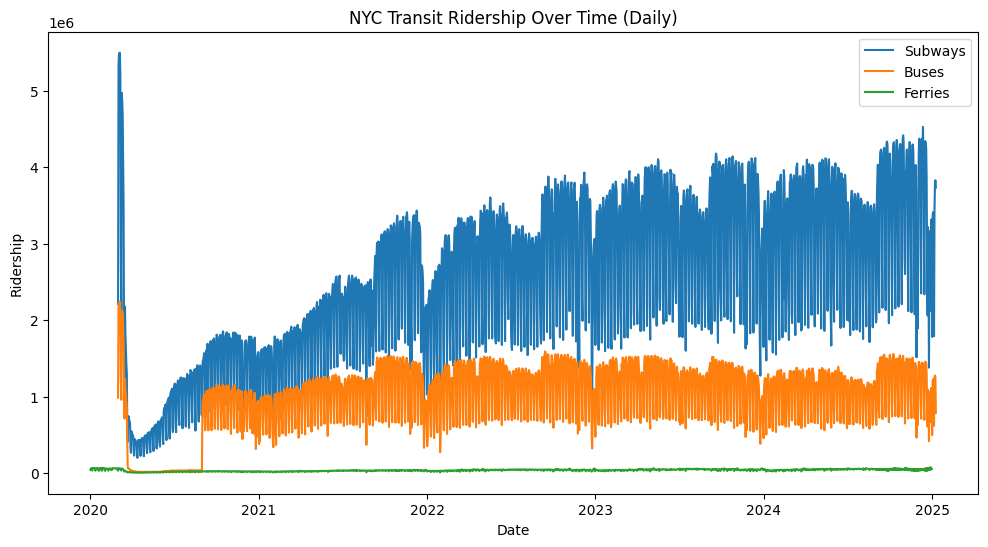

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12,6))

# # Subways
# plt.plot(subways['date'], subways['ridership'],
#          label='Subways')

# # Buses
# plt.plot(buses['date'], buses['ridership'],
#          label='Buses')

# # Ferries
# plt.plot(ferry_df['date'], ferry_df['ridership'],
#          label='Ferries')

# plt.title("NYC Transit Ridership Over Time (Daily)")
# plt.xlabel("Date")
# plt.ylabel("Ridership")
# plt.legend()

# plt.show()